# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [ ]:
# 코랩 환경: 구글 드라이브를 코랩에 연동
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# housing.xls가 포함된 경로를 저장해봅시다.

house = pd.read_excel("/content/drive/MyDrive/KUBIG_26_summer_basic_session_ML/week3/housing.xls")

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

과제2 참고

In [ ]:
# .head()
display(house.head())

# .info()
house.info()

# .describe()
display(house.describe())

# .shape
print(house.shape)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


(506, 14)


# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

In [ ]:
# NaN의 개수 구하기 (변수별로)
print(house.isnull().sum())

# NaN의 개수 구하기 (전체)
print("전체 결측치 개수:", house.isnull().sum().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
전체 결측치 개수: 0


### Q2 결과 해석

각 변수의 결측치 개수를 확인한 결과, 모든 변수에서 결측치가 0개로 나타났다. 따라서 별도의 결측치 처리 없이 분석을 진행한다.

# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

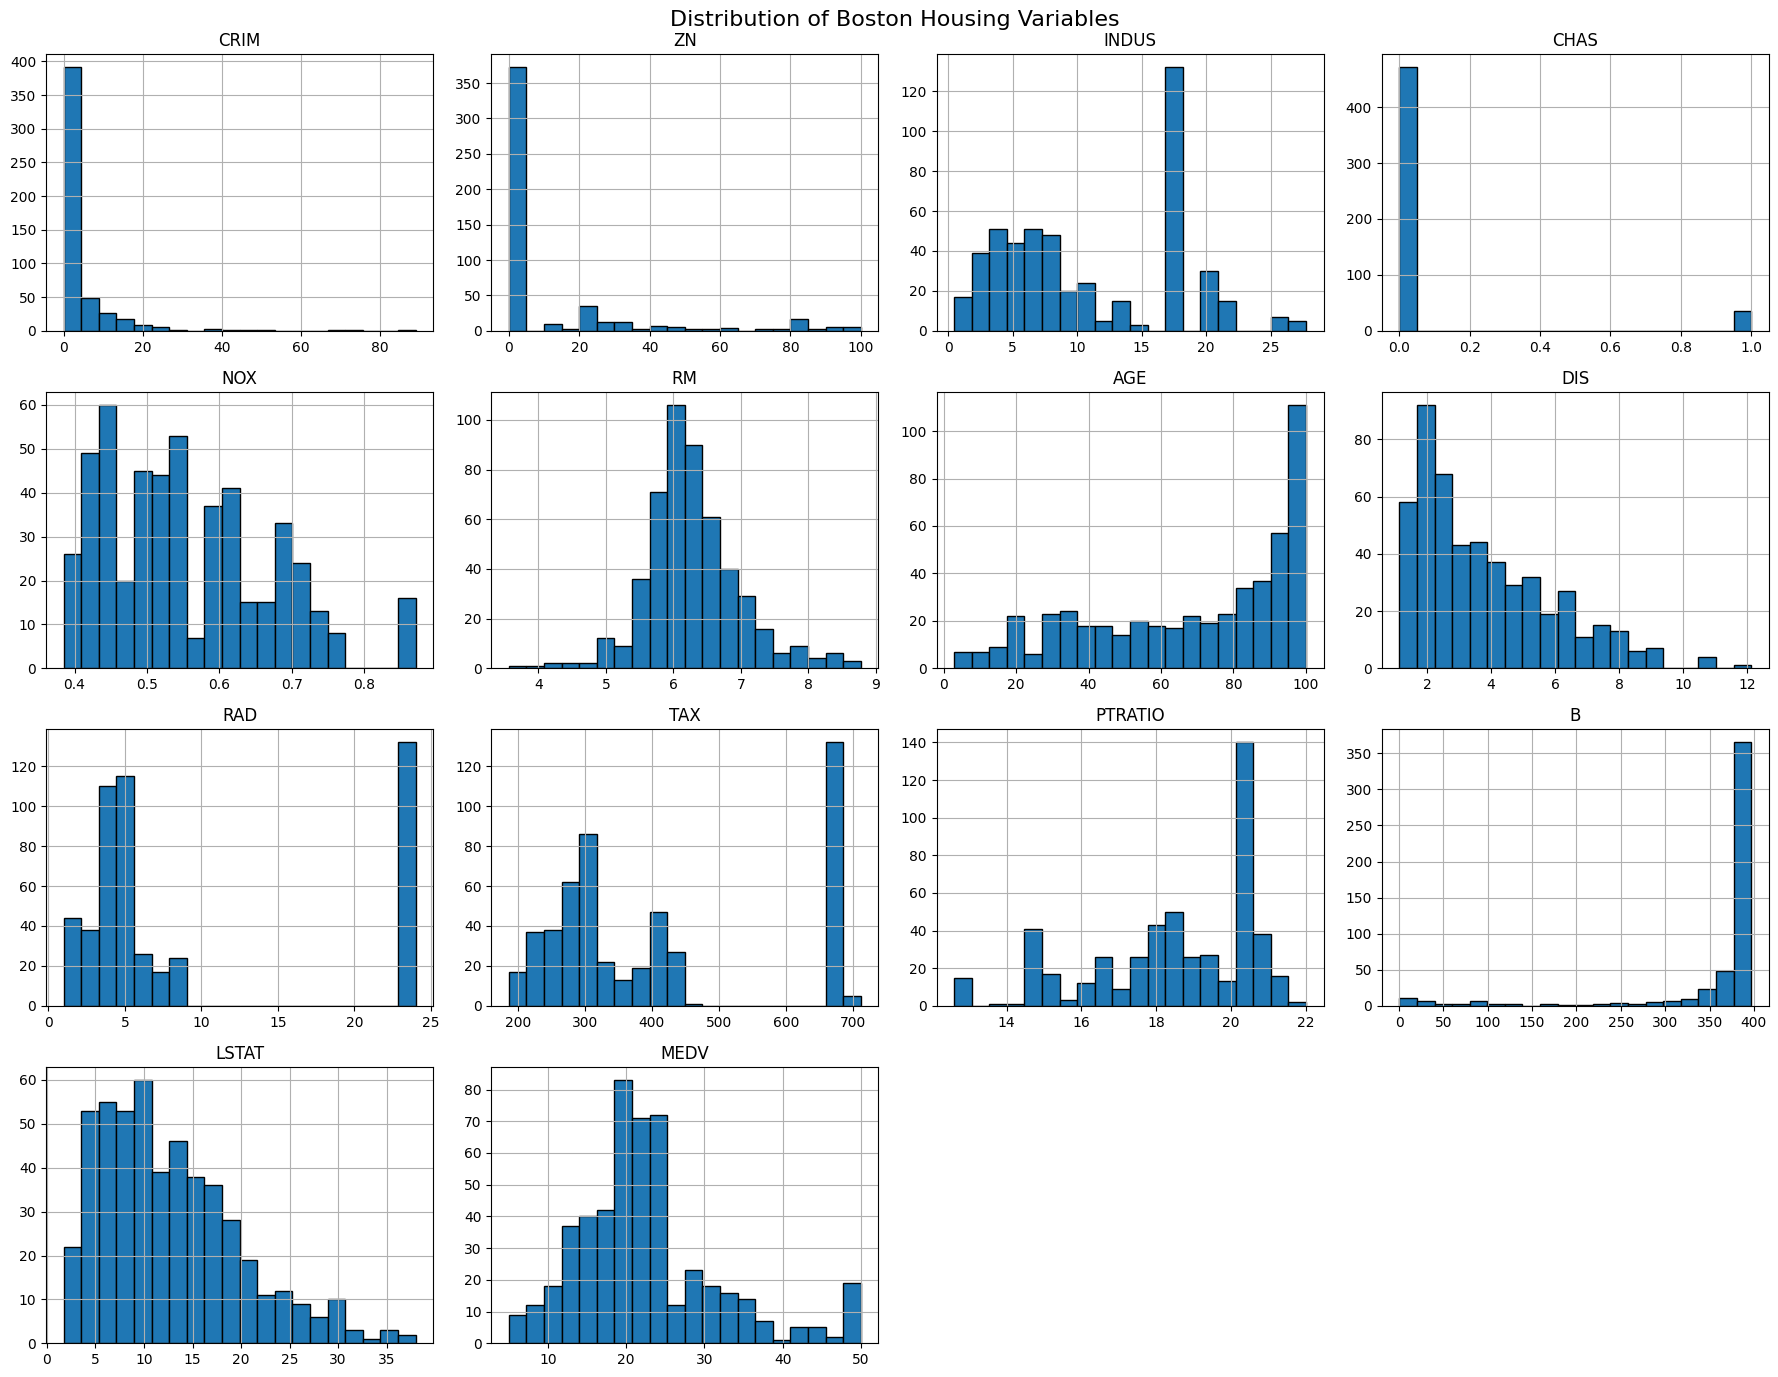

In [ ]:
# Histogram - 각 변수의 분포 확인
house.hist(
    bins=20,
    figsize=(18, 14),
    edgecolor="black"
)

plt.suptitle("Distribution of Boston Housing Variables", fontsize=16)
plt.tight_layout()
plt.show()

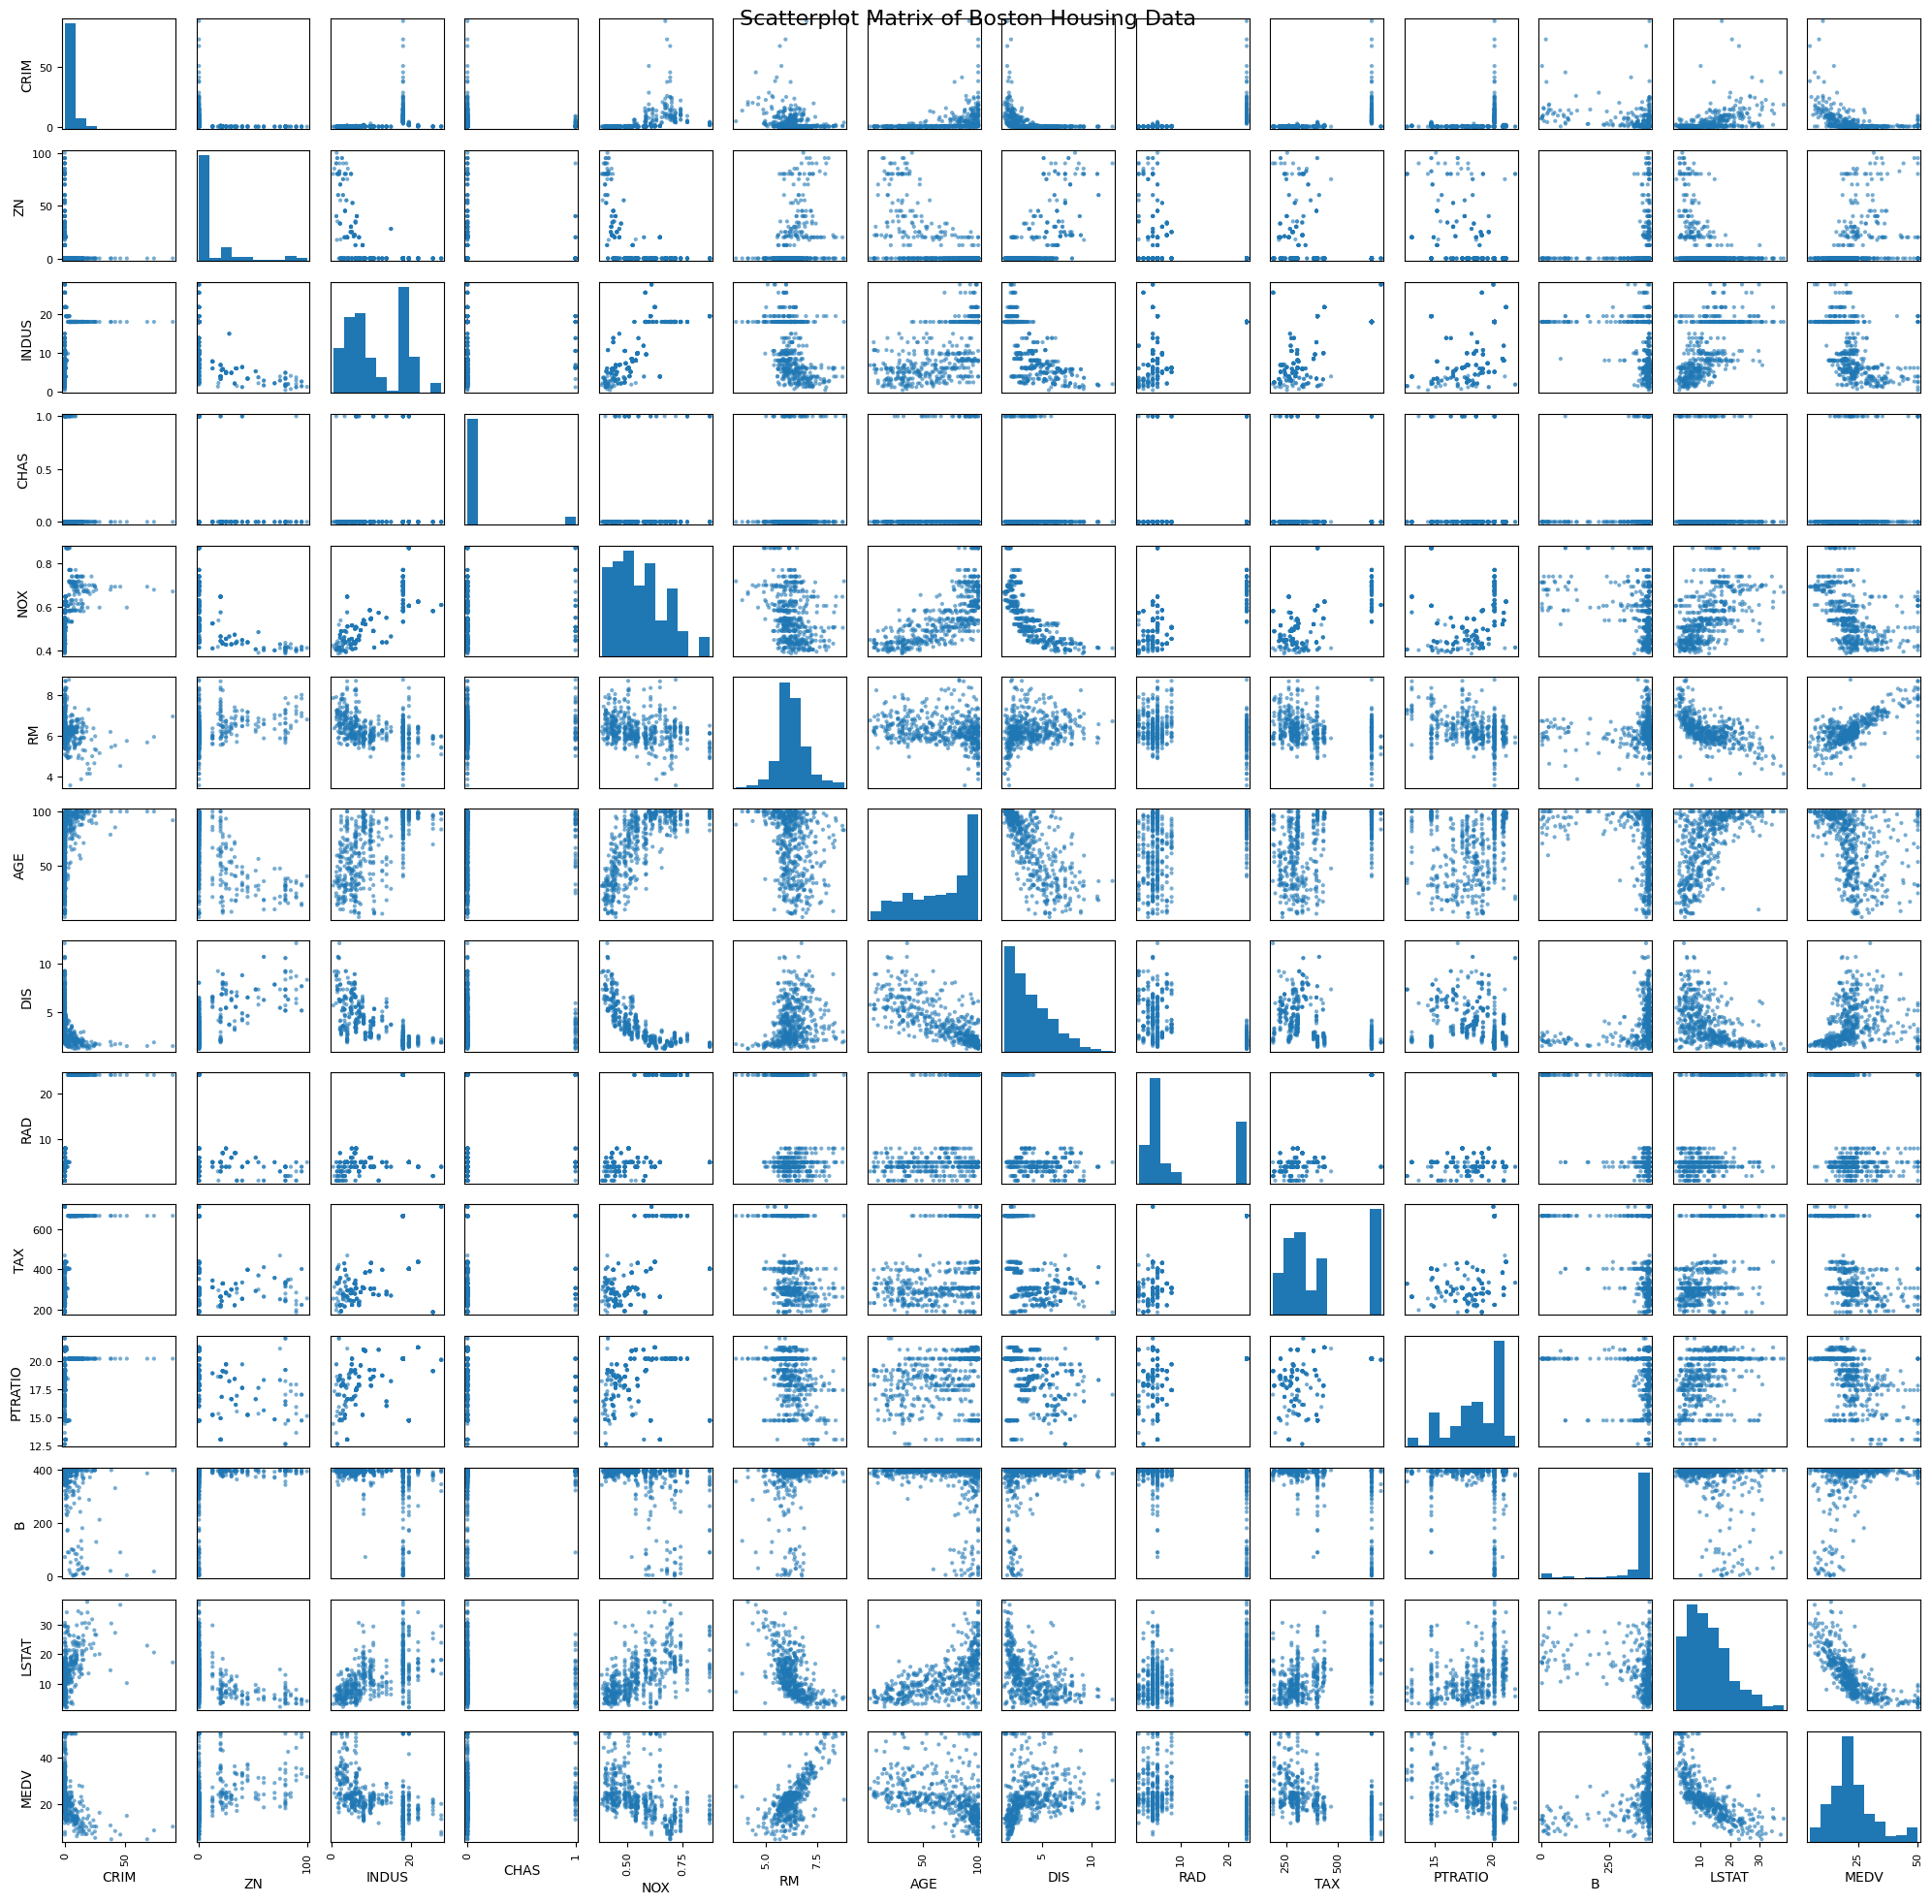

In [ ]:
# Scatterplot Matrix - 변수 간 관계 확인
pd.plotting.scatter_matrix(
    house,
    figsize=(20, 20),
    diagonal="hist",
    alpha=0.6
)

plt.suptitle("Scatterplot Matrix of Boston Housing Data", fontsize=16)
plt.tight_layout()
plt.show()

### Q3 결과 해석

히스토그램을 통해 CRIM과 ZN 등 일부 변수의 분포가 한쪽으로 치우쳐 있음을 확인하였다.  

Scatterplot Matrix에서는 RM과 MEDV 사이에 양의 관계가, LSTAT과 MEDV 사이에 음의 관계가 나타났다. 또한 RAD와 TAX 등 일부 설명변수 사이에도 비교적 강한 관계가 관찰되어 다중공선성 여부를 추가로 확인할 필요가 있다.

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

In [ ]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns
vif

,VIF Factor,features
0,2.131404,CRIM
1,2.910004,ZN
2,14.485874,INDUS
3,1.176266,CHAS
4,74.004269,NOX
5,136.101743,RM
6,21.398863,AGE
7,15.430455,DIS
8,15.369980,RAD
9,61.939713,TAX


## Q3-2.
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

In [ ]:
vif = pd.DataFrame()
x_data = house.drop( 'RM' ,axis=1) # VIF가 가장 높았던 RM을 먼저 넣었다.
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.110287,CRIM
1,2.889159,ZN
2,14.202832,INDUS
3,1.174535,CHAS
4,62.073615,NOX
5,20.752654,AGE
6,14.258330,DIS
7,15.134503,RAD
8,61.603579,TAX
9,69.068505,PTRATIO


In [ ]:
vif = pd.DataFrame()
x_data = house.drop( ["RM", "PTRATIO"] ,axis=1) # VIF 2순위까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.104099,CRIM
1,2.558330,ZN
2,14.147928,INDUS
3,1.162582,CHAS
4,59.247225,NOX
5,20.427509,AGE
6,9.639018,DIS
7,15.130157,RAD
8,58.759509,TAX
9,19.222365,B


In [ ]:
vif = pd.DataFrame()
x_data = house.drop( ["RM", "PTRATIO", "NOX"] ,axis=1) # VIF 3순위까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.103346,CRIM
1,2.548017,ZN
2,13.152242,INDUS
3,1.161474,CHAS
4,17.056895,AGE
5,9.446150,DIS
6,15.049247,RAD
7,54.753156,TAX
8,18.593595,B
9,11.031436,LSTAT


In [ ]:
vif = pd.DataFrame()
x_data = house.drop( ["RM", "PTRATIO", "NOX", "TAX"] ,axis=1) # VIF 4순위까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.103261,CRIM
1,2.465535,ZN
2,9.024818,INDUS
3,1.142745,CHAS
4,16.449470,AGE
5,8.722321,DIS
6,4.858231,RAD
7,18.131319,B
8,10.934458,LSTAT
9,11.385287,MEDV


In [ ]:
vif = pd.DataFrame()
x_data = house.drop( ["RM", "PTRATIO", "NOX", "TAX", "B"] ,axis=1) # VIF 5순위까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.095925,CRIM
1,2.421949,ZN
2,8.855666,INDUS
3,1.142321,CHAS
4,15.731199,AGE
5,6.518545,DIS
6,4.733212,RAD
7,10.641862,LSTAT
8,8.500366,MEDV


In [ ]:
vif = pd.DataFrame()
x_data = house.drop( ["RM", "PTRATIO", "NOX", "TAX", "B","AGE"] ,axis=1) # VIF 6순위까지 제거
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.095110,CRIM
1,2.317242,ZN
2,8.044685,INDUS
3,1.141690,CHAS
4,6.395977,DIS
5,4.727054,RAD
6,7.012987,LSTAT
7,5.630097,MEDV


### Q3-2 결과 해석
변수를 하나씩 제거했을 때, VIF가 가장 큰 변수들부터 하나씩 제거한 결과, 6개를 제거했을 때 모든 VIF가 10보다 작게 나왔다

**house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

In [ ]:
# train_test_split

# 설명변수와 목표변수 분리
X = house.drop("MEDV", axis=1)
y = house["MEDV"]

# 학습 데이터와 테스트 데이터를 8:2로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 분할 결과 확인
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [ ]:
# StandardScaler
scale_columns = [
    "CRIM", "ZN", "INDUS", "NOX", "RM",
    "AGE", "DIS", "TAX", "PTRATIO", "B", "LSTAT"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

display(X_train_scaled.head())

# 표준화가 잘 되었는지 확인
print("표준화된 학습 데이터 평균:")
print(X_train_scaled[scale_columns].mean().round(3))

print("\n표준화된 학습 데이터 표준편차:")
print(X_train_scaled[scale_columns].std(ddof=0).round(3))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,0,0.489252,-1.428069,1.028015,-0.802173,24,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,0,-0.157233,-0.680087,-0.431199,0.324349,4,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,0,-1.008723,-0.402063,-1.618599,1.330697,1,-0.602724,-0.637176,0.065297,-0.651595
423,0.388230,-0.500320,1.033237,0,0.489252,-0.300450,0.591681,-0.839240,24,1.578434,0.845343,-3.868193,1.525387
19,-0.325282,-0.500320,-0.413160,0,-0.157233,-0.831094,0.033747,-0.005494,4,-0.584648,1.204741,0.379119,-0.165787


표준화된 학습 데이터 평균:
CRIM      -0.0
ZN         0.0
INDUS     -0.0
NOX       -0.0
RM        -0.0
AGE       -0.0
DIS        0.0
TAX       -0.0
PTRATIO    0.0
B         -0.0
LSTAT     -0.0
dtype: float64

표준화된 학습 데이터 표준편차:
CRIM       1.0
ZN         1.0
INDUS      1.0
NOX        1.0
RM         1.0
AGE        1.0
DIS        1.0
TAX        1.0
PTRATIO    1.0
B          1.0
LSTAT      1.0
dtype: float64


표준화가 잘 이루어졌습니다~

# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

In [ ]:
# KFold를 이용한 5-fold Cross-Validation

from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# 5-fold 교차검증 설정
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Fold별 결과 저장
evaluation_results = []
coefficient_results = []

# 각 Fold에서 모델 학습 및 검증
for fold, (train_index, val_index) in enumerate(
    kf.split(X_train_scaled),
    start=1
):
    # 현재 Fold의 학습·검증 데이터
    X_fold_train = X_train_scaled.iloc[train_index]
    X_fold_val = X_train_scaled.iloc[val_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]

    # 선형회귀 모델 학습
    model = LinearRegression()
    model.fit(X_fold_train, y_fold_train)

    # 검증 데이터 예측
    y_fold_pred = model.predict(X_fold_val)

    # 평가 지표 계산
    mse = mean_squared_error(y_fold_val, y_fold_pred)
    mae = mean_absolute_error(y_fold_val, y_fold_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_fold_val, y_fold_pred)

    # Fold별 평가 결과 저장
    evaluation_results.append({
        "Fold": fold,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    # Fold별 절편 저장
    fold_coefficients = {
        "Fold": fold,
        "Intercept": model.intercept_
    }

    # 변수별 회귀계수 저장
    fold_coefficients.update(
        dict(zip(X_train_scaled.columns, model.coef_))
    )

    coefficient_results.append(fold_coefficients)


# Fold별 평가 결과 표
cv_results = pd.DataFrame(evaluation_results)

print("===== 5-Fold 평가 결과 =====")
display(cv_results.round(4))


# Fold별 절편과 회귀계수 표
coefficient_df = pd.DataFrame(coefficient_results)

print("===== 5-Fold 회귀계수 및 절편 =====")
display(coefficient_df.round(4))


# 5개 Fold의 평균 성능
print("===== 5-Fold 평균 성능 =====")
print(f"Mean MSE  : {cv_results['MSE'].mean():.4f}")
print(f"Mean MAE  : {cv_results['MAE'].mean():.4f}")
print(f"Mean RMSE : {cv_results['RMSE'].mean():.4f}")
print(f"Mean R²   : {cv_results['R²'].mean():.4f}")

===== 5-Fold 평가 결과 =====


,Fold,MSE,MAE,RMSE,R²
0,1,23.2864,3.2108,4.8256,0.6725
1,2,23.5646,3.4965,4.8543,0.7601
2,3,36.4745,3.7736,6.0394,0.5895
3,4,25.7558,3.9217,5.0750,0.7592
4,5,12.5105,2.7395,3.5370,0.8112


===== 5-Fold 회귀계수 및 절편 =====


,Fold,Intercept,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1,20.5048,-0.9481,0.7586,0.3009,3.0076,-2.2275,3.5129,-0.0702,-3.2193,0.2202,-1.4567,-2.0815,1.1573,-3.2812
1,2,20.1013,-1.0581,0.7422,0.1049,3.0930,-2.0143,2.7999,-0.1748,-3.3261,0.2430,-1.7421,-1.7766,1.0934,-3.9721
2,3,20.5784,-0.8396,0.6840,0.5637,0.6283,-1.6412,3.4941,-0.3119,-2.6510,0.2250,-2.0508,-2.1805,1.2383,-2.9970
3,4,19.8610,-1.0337,0.3269,-0.0331,4.6142,-1.9962,2.9200,-0.2925,-2.8870,0.2852,-1.4279,-2.1351,1.0205,-3.9890
4,5,19.6980,-1.0966,0.8967,0.4574,2.5334,-2.2169,3.0900,-0.0464,-3.2372,0.3314,-2.2369,-2.0919,1.1487,-3.5907


===== 5-Fold 평균 성능 =====
Mean MSE  : 24.3184
Mean MAE  : 3.4284
Mean RMSE : 4.8663
Mean R²   : 0.7185


### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

In [ ]:
# 다중공선성을 불러일으키는 변수 제거 - 아까 구한 6개의 변수를 사용

house_new = house.drop(["RM", "PTRATIO", "NOX","TAX", "B", "AGE"], axis=1) # VIF 높은 변수 6개

In [ ]:
#1 train_test_split
X_new = house_new.drop("MEDV", axis=1)
y_new = house_new["MEDV"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)

print("\n분할 결과")
print("X_train_new shape:", X_train_new.shape)
print("X_test_new shape:", X_test_new.shape)
print("y_train_new shape:", y_train_new.shape)
print("y_test_new shape:", y_test_new.shape)

#2 StandardScaler
#2-1 남아 있는 변수 중 표준화할 변수
scale_columns_new = [
    "CRIM", "ZN", "INDUS", "DIS", "LSTAT"
]


#2-2 원본 데이터 보존
X_train_new_scaled = X_train_new.copy()
X_test_new_scaled = X_test_new.copy()

#2-3 표준화
scaler_new = StandardScaler()

X_train_new_scaled[scale_columns_new] = (
    scaler_new.fit_transform(
        X_train_new[scale_columns_new]
    )
)

X_test_new_scaled[scale_columns_new] = (
    scaler_new.transform(
        X_test_new[scale_columns_new]
    )
)



#3 KFold, cross_val_score, cross_validation 이용
#3-1 5-fold 교차검증 설정
kf_new = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#3-2 Fold별 결과 저장
evaluation_results_new = []
coefficient_results_new = []


#3-3 각 Fold에서 모델 학습 및 검증
for fold, (train_index, val_index) in enumerate(
    kf_new.split(X_train_new_scaled),
    start=1
):
    # 현재 Fold의 학습·검증 데이터
    X_fold_train_new = X_train_new_scaled.iloc[train_index]
    X_fold_val_new = X_train_new_scaled.iloc[val_index]

    y_fold_train_new = y_train_new.iloc[train_index]
    y_fold_val_new = y_train_new.iloc[val_index]

    # 선형회귀 모델 학습
    model_new = LinearRegression()
    model_new.fit(X_fold_train_new, y_fold_train_new)

    # 검증 데이터 예측
    y_fold_pred_new = model_new.predict(X_fold_val_new)

    # 평가 지표 계산
    mse_new = mean_squared_error(
        y_fold_val_new,
        y_fold_pred_new
    )

    mae_new = mean_absolute_error(
        y_fold_val_new,
        y_fold_pred_new
    )

    rmse_new = np.sqrt(mse_new)

    r2_new = r2_score(
        y_fold_val_new,
        y_fold_pred_new
    )

    # Fold별 평가 결과 저장
    evaluation_results_new.append({
        "Fold": fold,
        "MSE": mse_new,
        "MAE": mae_new,
        "RMSE": rmse_new,
        "R²": r2_new
    })

    # Fold별 절편 저장
    fold_coefficients_new = {
        "Fold": fold,
        "Intercept": model_new.intercept_
    }

    # 변수별 회귀계수 저장
    fold_coefficients_new.update(
        dict(
            zip(
                X_train_new_scaled.columns,
                model_new.coef_
            )
        )
    )

    coefficient_results_new.append(
        fold_coefficients_new
    )


#3-4 Fold별 평가 결과 표
cv_results_new = pd.DataFrame(
    evaluation_results_new
)

print("\n===== 변수 제거 모델: 5-Fold 평가 결과 =====")
display(cv_results_new.round(4))


#3-5 Fold별 절편 및 회귀계수 표
coefficient_df_new = pd.DataFrame(
    coefficient_results_new
)

print("===== 변수 제거 모델: 회귀계수 및 절편 =====")
display(coefficient_df_new.round(4))


#3-6 변수 제거 모델의 평균 성능
print("===== 변수 제거 모델: 평균 성능 =====")
print(f"Mean MSE  : {cv_results_new['MSE'].mean():.4f}")
print(f"Mean MAE  : {cv_results_new['MAE'].mean():.4f}")
print(f"Mean RMSE : {cv_results_new['RMSE'].mean():.4f}")
print(f"Mean R²   : {cv_results_new['R²'].mean():.4f}")




분할 결과
X_train_new shape: (404, 7)
X_test_new shape: (102, 7)
y_train_new shape: (404,)
y_test_new shape: (102,)

===== 변수 제거 모델: 5-Fold 평가 결과 =====


,Fold,MSE,MAE,RMSE,R²
0,1,24.8317,3.7680,4.9831,0.6507
1,2,41.4869,4.4288,6.4410,0.5776
2,3,39.4284,4.5579,6.2792,0.5562
3,4,39.9305,4.7700,6.3191,0.6266
4,5,22.6450,3.7683,4.7587,0.6583


===== 변수 제거 모델: 회귀계수 및 절편 =====


,Fold,Intercept,CRIM,ZN,INDUS,CHAS,DIS,RAD,LSTAT
0,1,22.7377,-1.0620,1.9212,-2.0196,4.1909,-4.2506,-0.0300,-6.3287
1,2,22.6093,-1.0021,1.7079,-1.8872,4.4152,-3.5690,-0.0303,-6.2604
2,3,23.0969,-0.9894,1.8361,-1.6496,2.9560,-3.8248,-0.0532,-6.3035
3,4,22.1136,-1.1068,1.2666,-1.9330,5.4541,-3.3403,0.0289,-6.3618
4,5,22.2264,-1.5194,1.9493,-2.3886,3.9961,-4.1013,0.0469,-6.1988


===== 변수 제거 모델: 평균 성능 =====
Mean MSE  : 33.6645
Mean MAE  : 4.2586
Mean RMSE : 5.7562
Mean R²   : 0.6139


In [ ]:
# Q6 전체 변수 모델과 Q6-1 변수 제거 모델 비교
comparison = pd.DataFrame({
    "전체 변수 모델": [
        cv_results["MSE"].mean(),
        cv_results["MAE"].mean(),
        cv_results["RMSE"].mean(),
        cv_results["R²"].mean()
    ],
    "변수 제거 모델": [
        cv_results_new["MSE"].mean(),
        cv_results_new["MAE"].mean(),
        cv_results_new["RMSE"].mean(),
        cv_results_new["R²"].mean()
    ]
}, index=["MSE", "MAE", "RMSE", "R²"])

print("\n===== 전체 변수 모델과 변수 제거 모델 비교 =====")
display(comparison.round(4))


===== 전체 변수 모델과 변수 제거 모델 비교 =====


,전체 변수 모델,변수 제거 모델
MSE,24.3184,33.6645
MAE,3.4284,4.2586
RMSE,4.8663,5.7562
R²,0.7185,0.6139


### Q6-1 결과 해석

전체 변수를 사용한 모델과 다중공선성이 높게 나타난 변수를 제거한
모델의 5-fold 교차검증 성능을 비교하였다.

전체 변수 모델의 평균 MSE는 24.3184, MAE는 3.4284, RMSE는
4.8663으로 나타났으며, 평균 R²는 약 0.7185였다. 반면 변수 제거
모델은 평균 MSE 33.6645, MAE 4.2586, RMSE 5.7562, R² 약
0.6129로 나타났다.

변수 제거 모델은 전체 변수 모델보다 모든 오차 지표가 증가하고
R²가 감소하였다. 이는 다중공선성이 높은 변수를 제거하는 과정에서
주택가격 예측에 유용한 정보까지 함께 제거되었기 때문으로
해석할 수 있다.

따라서 VIF가 높다는 이유만으로 변수를 기계적으로 제거하기보다는,
변수의 의미와 목표변수와의 관계, 제거 전후의 교차검증 성능을 함께
고려해야 한다. 본 분석에서는 전체 변수를 사용한 모델의 예측 성능이
더 우수한 것으로 나타났다.

# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

In [ ]:
# Q7: GridSearchCV를 이용한 Lasso 적합

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso


# 탐색할 하이퍼파라미터
param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "fit_intercept": [True, False]
}


# 세 가지 평가 지표
# GridSearchCV는 오차 지표를 음수 형태로 반환함
scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R²": "r2"
}


# Lasso 모델
lasso = Lasso(
    max_iter=10000
)


# GridSearchCV 설정
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring=scoring,
    refit="MSE",
    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    n_jobs=-1,
    return_train_score=False
)


# 전체 변수 학습 데이터로 모델 적합
grid_search.fit(
    X_train_scaled,
    y_train
)


# 모든 조합의 교차검증 결과
grid_cv_results = pd.DataFrame(
    grid_search.cv_results_
)


# 필요한 결과만 정리
grid_summary = pd.DataFrame({
    "alpha": grid_cv_results["param_alpha"],
    "fit_intercept": (
        grid_cv_results["param_fit_intercept"]
    ),
    "Mean CV MSE": (
        -grid_cv_results["mean_test_MSE"]
    ),
    "Mean CV MAE": (
        -grid_cv_results["mean_test_MAE"]
    ),
    "Mean CV R²": (
        grid_cv_results["mean_test_R²"]
    )
})


# MSE가 낮은 순서로 정렬
grid_summary = grid_summary.sort_values(
    by="Mean CV MSE",
    ascending=True
).reset_index(drop=True)


print("===== Lasso GridSearchCV 전체 결과 =====")
display(grid_summary.round(4))


# 최적 하이퍼파라미터
print("===== 최적 하이퍼파라미터 =====")
print(grid_search.best_params_)


# 최적 조합의 CV 결과
best_index = grid_search.best_index_

best_cv_mse = -grid_search.cv_results_[
    "mean_test_MSE"
][best_index]

best_cv_mae = -grid_search.cv_results_[
    "mean_test_MAE"
][best_index]

best_cv_r2 = grid_search.cv_results_[
    "mean_test_R²"
][best_index]

best_cv_rmse = np.sqrt(best_cv_mse)


print("\n===== 최적 Lasso의 평균 CV 성능 =====")
print(f"Mean CV MSE  : {best_cv_mse:.4f}")
print(f"Mean CV MAE  : {best_cv_mae:.4f}")
print(f"Mean CV RMSE : {best_cv_rmse:.4f}")
print(f"Mean CV R²   : {best_cv_r2:.4f}")


# 최적 모델
best_lasso = grid_search.best_estimator_


# 별도로 보관한 테스트 데이터 예측
y_test_pred_lasso = best_lasso.predict(
    X_test_scaled
)


# 테스트 데이터 평가
test_mse_lasso = mean_squared_error(
    y_test,
    y_test_pred_lasso
)

test_mae_lasso = mean_absolute_error(
    y_test,
    y_test_pred_lasso
)

test_rmse_lasso = np.sqrt(
    test_mse_lasso
)

test_r2_lasso = r2_score(
    y_test,
    y_test_pred_lasso
)


print("\n===== 최적 Lasso의 테스트 성능 =====")
print(f"Test MSE  : {test_mse_lasso:.4f}")
print(f"Test MAE  : {test_mae_lasso:.4f}")
print(f"Test RMSE : {test_rmse_lasso:.4f}")
print(f"Test R²   : {test_r2_lasso:.4f}")


# 최적 모델의 절편 및 회귀계수
lasso_coefficients = pd.DataFrame({
    "Variable": X_train_scaled.columns,
    "Coefficient": best_lasso.coef_
})

print("\n===== 최적 Lasso의 절편 =====")
print(round(best_lasso.intercept_, 4))

print("\n===== 최적 Lasso의 회귀계수 =====")
display(lasso_coefficients.round(4))


# 계수가 0이 된 변수 확인
zero_coefficient_variables = (
    lasso_coefficients.loc[
        lasso_coefficients["Coefficient"] == 0,
        "Variable"
    ].tolist()
)

print(
    "계수가 0이 된 변수:",
    zero_coefficient_variables
)

===== Lasso GridSearchCV 전체 결과 =====


,alpha,fit_intercept,Mean CV MSE,Mean CV MAE,Mean CV R²
0,0.01,True,24.3201,3.4192,0.7185
1,0.10,True,24.5503,3.3756,0.7157
2,1.00,True,31.4323,3.8403,0.6349
3,0.01,False,70.2647,6.3645,0.1740
4,0.10,False,70.5175,6.3447,0.1740
5,10.00,True,76.6783,6.4391,0.1183
6,1.00,False,78.5533,6.5282,0.0938
7,10.00,False,302.3490,15.2920,-2.5429


===== 최적 하이퍼파라미터 =====
{'alpha': 0.01, 'fit_intercept': True}

===== 최적 Lasso의 평균 CV 성능 =====
Mean CV MSE  : 24.3201
Mean CV MAE  : 3.4192
Mean CV RMSE : 4.9315
Mean CV R²   : 0.7185

===== 최적 Lasso의 테스트 성능 =====
Test MSE  : 24.2854
Test MAE  : 3.1782
Test RMSE : 4.9280
Test R²   : 0.6688

===== 최적 Lasso의 절편 =====
20.2621

===== 최적 Lasso의 회귀계수 =====


,Variable,Coefficient
0,CRIM,-0.9855
1,ZN,0.6542
2,INDUS,0.2049
3,CHAS,2.6571
4,NOX,-1.9603
5,RM,3.1471
6,AGE,-0.1490
7,DIS,-3.0146
8,RAD,0.2505
9,TAX,-1.6557


계수가 0이 된 변수: []


### Q7 결과 해석

GridSearchCV를 이용하여 Lasso의 `alpha`와 `fit_intercept` 조합을
5-fold 교차검증으로 비교하였다. MSE를 최종 모델 선택 기준으로
사용한 결과, 최적 하이퍼파라미터는 `alpha=0.01`,
`fit_intercept=True`로 나타났다.

최적 Lasso 모델의 평균 CV 성능은 MSE 24.3201, MAE 3.4192,
RMSE 4.9315, R² 0.7185로 나타났다. 테스트 데이터에서는
MSE 24.2854, MAE 3.1782, RMSE 4.9280, R² 0.6688의
성능을 보였다.

선택된 `alpha=0.01`은 후보 중 가장 작은 값이므로, 이 데이터에서는
강한 규제보다 일반 선형회귀에 가까운 약한 규제가 더 적합했음을
의미한다. 또한 최적 모델에서 계수가 정확히 0이 된 변수는 없었으므로,
이번 탐색 범위에서는 Lasso에 의한 뚜렷한 변수 선택 효과가 나타나지
않았다.

`fit_intercept=True`가 선택된 것은 설명변수는 표준화했지만 목표변수
MEDV는 평균 0으로 변환하지 않았기 때문에 절편을 포함하는 것이 더
적절했기 때문으로 해석할 수 있다.

# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

In [ ]:
# Q8: RandomizedSearchCV를 이용한 Ridge 적합

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import loguniform


# 탐색할 하이퍼파라미터 공간
param_distributions = {
    # 0.0001부터 1000 사이에서 로그 단위로 alpha 추출
    "alpha": loguniform(1e-4, 1e3),

    # 절편 사용 여부
    "fit_intercept": [True, False]
}


# 세 가지 평가 지표
scoring_ridge = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R²": "r2"
}


# Ridge 모델
ridge = Ridge(
    max_iter=10000
)


# RandomizedSearchCV 설정
random_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=scoring_ridge,
    refit="MSE",
    cv=KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    random_state=42,
    n_jobs=-1,
    return_train_score=False
)


# 전체 변수 학습 데이터로 탐색
random_search.fit(
    X_train_scaled,
    y_train
)


# 전체 탐색 결과
ridge_cv_results = pd.DataFrame(
    random_search.cv_results_
)


# 필요한 결과만 정리
ridge_summary = pd.DataFrame({
    "alpha": ridge_cv_results["param_alpha"],
    "fit_intercept": (
        ridge_cv_results["param_fit_intercept"]
    ),
    "Mean CV MSE": (
        -ridge_cv_results["mean_test_MSE"]
    ),
    "Mean CV MAE": (
        -ridge_cv_results["mean_test_MAE"]
    ),
    "Mean CV R²": (
        ridge_cv_results["mean_test_R²"]
    )
})


# MSE가 낮은 순서로 정렬
ridge_summary = ridge_summary.sort_values(
    by="Mean CV MSE",
    ascending=True
).reset_index(drop=True)


print("===== Ridge RandomizedSearchCV 결과 =====")
display(ridge_summary.round(4))


# 최적 하이퍼파라미터
print("===== 최적 하이퍼파라미터 =====")
print(random_search.best_params_)


# 최적 조합의 CV 성능
best_ridge_index = random_search.best_index_

best_ridge_cv_mse = -random_search.cv_results_[
    "mean_test_MSE"
][best_ridge_index]

best_ridge_cv_mae = -random_search.cv_results_[
    "mean_test_MAE"
][best_ridge_index]

best_ridge_cv_r2 = random_search.cv_results_[
    "mean_test_R²"
][best_ridge_index]

best_ridge_cv_rmse = np.sqrt(
    best_ridge_cv_mse
)


print("\n===== 최적 Ridge의 평균 CV 성능 =====")
print(f"Mean CV MSE  : {best_ridge_cv_mse:.4f}")
print(f"Mean CV MAE  : {best_ridge_cv_mae:.4f}")
print(f"Mean CV RMSE : {best_ridge_cv_rmse:.4f}")
print(f"Mean CV R²   : {best_ridge_cv_r2:.4f}")


# 최적 Ridge 모델
best_ridge = random_search.best_estimator_


# 테스트 데이터 예측
y_test_pred_ridge = best_ridge.predict(
    X_test_scaled
)


# 테스트 데이터 평가
test_mse_ridge = mean_squared_error(
    y_test,
    y_test_pred_ridge
)

test_mae_ridge = mean_absolute_error(
    y_test,
    y_test_pred_ridge
)

test_rmse_ridge = np.sqrt(
    test_mse_ridge
)

test_r2_ridge = r2_score(
    y_test,
    y_test_pred_ridge
)


print("\n===== 최적 Ridge의 테스트 성능 =====")
print(f"Test MSE  : {test_mse_ridge:.4f}")
print(f"Test MAE  : {test_mae_ridge:.4f}")
print(f"Test RMSE : {test_rmse_ridge:.4f}")
print(f"Test R²   : {test_r2_ridge:.4f}")


# 최적 Ridge 모델의 회귀계수
ridge_coefficients = pd.DataFrame({
    "Variable": X_train_scaled.columns,
    "Coefficient": best_ridge.coef_
})

print("\n===== 최적 Ridge의 절편 =====")
print(round(best_ridge.intercept_, 4))

print("\n===== 최적 Ridge의 회귀계수 =====")
display(ridge_coefficients.round(4))

===== Ridge RandomizedSearchCV 결과 =====


,alpha,fit_intercept,Mean CV MSE,Mean CV MAE,Mean CV R²
0,1.9124,True,24.2124,3.4123,0.7196
1,1.7898,True,24.2180,3.4132,0.7195
2,1.5510,True,24.2294,3.4150,0.7194
3,0.4714,True,24.2884,3.4241,0.7188
4,0.1851,True,24.3063,3.4267,0.7186
5,0.1558,True,24.3082,3.4270,0.7186
6,0.1321,True,24.3097,3.4272,0.7186
7,0.1205,True,24.3104,3.4273,0.7186
8,0.1056,True,24.3114,3.4274,0.7186
9,0.0419,True,24.3156,3.4280,0.7185


===== 최적 하이퍼파라미터 =====
{'alpha': np.float64(1.9123708862553228), 'fit_intercept': True}

===== 최적 Ridge의 평균 CV 성능 =====
Mean CV MSE  : 24.2124
Mean CV MAE  : 3.4123
Mean CV RMSE : 4.9206
Mean CV R²   : 0.7196

===== 최적 Ridge의 테스트 성능 =====
Test MSE  : 24.2807
Test MAE  : 3.1800
Test RMSE : 4.9275
Test R²   : 0.6689

===== 최적 Ridge의 절편 =====
20.2176

===== 최적 Ridge의 회귀계수 =====


,Variable,Coefficient
0,CRIM,-0.9965
1,ZN,0.6703
2,INDUS,0.2511
3,CHAS,2.6115
4,NOX,-1.9616
5,RM,3.1531
6,AGE,-0.1730
7,DIS,-3.0158
8,RAD,0.2556
9,TAX,-1.7108


### Q8 결과 해석

RandomizedSearchCV를 이용하여 Ridge의 `alpha`와
`fit_intercept`를 탐색하였다. 총 30개의 하이퍼파라미터 조합을
5-fold 교차검증으로 비교했으며, MSE를 최종 모델 선택 기준으로
사용하였다.

최적 하이퍼파라미터는 `alpha` 약 1.9124,
`fit_intercept=True`로 나타났다. 최적 Ridge 모델의 평균 CV
성능은 MSE 24.2124, MAE 3.4123, RMSE 4.9206,
R² 0.7196이었다. 테스트 데이터에서는 MSE 24.2807,
MAE 3.1800, RMSE 4.9275, R² 0.6689의 성능을 보였다.

Ridge는 L2 규제를 이용하여 모든 회귀계수를 유지하면서 그 크기를
축소한다. 따라서 Lasso처럼 일부 계수를 정확히 0으로 만들지는
않지만, 서로 상관관계가 있는 설명변수들의 영향을 보다 안정적으로
분산할 수 있다.

이번 결과에서 Ridge는 Lasso보다 CV MSE가 조금 낮고 R²가 조금
높았으나 차이는 매우 작았다. 테스트 성능 역시 두 모델이 거의
동일하게 나타났다. 따라서 Ridge 규제가 성능을 크게 개선했다고
보기는 어렵지만, 전체 변수의 정보를 유지하면서 회귀계수를 안정화한
모델이라는 의미가 있다.

# 다른 분석 : Q3-1의 VIF 산출 방식을 바꿔보면..?
1. Q3-1을 조금 수정해봤다. (목표변수를 제외하고, 상수항을 추가했다.)
2. 이를 기준으로 VIF를 다시 분석하고 제거할 변수를 다시 정했다.
3. 어떤 결과가 나올지 확인해보자!

In [ ]:
# 수정된 방법으로 VIF 계산
# 1. 목표변수 MEDV 제외
# 2. 상수항 추가

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 목표변수를 제외한 설명변수
X_vif_corrected = house.drop(columns="MEDV")

# 상수항 추가
X_vif_corrected_const = add_constant(
    X_vif_corrected,
    has_constant="add"
)

# VIF 계산
vif_corrected = pd.DataFrame({
    "features": X_vif_corrected_const.columns,
    "VIF Factor": [
        variance_inflation_factor(
            X_vif_corrected_const.values,
            i
        )
        for i in range(X_vif_corrected_const.shape[1])
    ]
})

# VIF가 높은 순서로 정렬
vif_corrected = vif_corrected.sort_values(
    by="VIF Factor",
    ascending=False
).reset_index(drop=True)

print("===== 수정된 방법의 VIF =====")
display(vif_corrected.round(4))

===== 수정된 방법의 VIF =====


,features,VIF Factor
0,const,585.2652
1,TAX,9.0086
2,RAD,7.4845
3,NOX,4.3937
4,INDUS,3.9916
5,DIS,3.9559
6,AGE,3.1008
7,LSTAT,2.9415
8,ZN,2.2988
9,RM,1.9337


## 수정된 방식의 VIF 해석
이렇게 보면 사실 10보다 큰 심각한 수준의 VIF는 확인되지 않는다. 즉, 아까 기준대로였으면 그대로 진행했을 것이다.

그러나 이번에는 실험을 위해 이번에는 기준을 VIF 미만으로 더 엄격하게 진행해보겠다.

In [ ]:
# VIF가 가장 높은 TAX를 먼저 제거
removed_columns_corrected = ["TAX"]

X_vif_after_removal = house.drop(
    columns=["MEDV"] + removed_columns_corrected
)

# 상수항 추가
X_vif_after_removal_const = add_constant(
    X_vif_after_removal,
    has_constant="add"
)

# TAX 제거 후 VIF 재계산
vif_after_removal = pd.DataFrame({
    "features": X_vif_after_removal_const.columns,
    "VIF Factor": [
        variance_inflation_factor(
            X_vif_after_removal_const.values,
            i
        )
        for i in range(X_vif_after_removal_const.shape[1])
    ]
})

vif_after_removal = vif_after_removal.sort_values(
    by="VIF Factor",
    ascending=False
).reset_index(drop=True)

print("제거한 변수:", removed_columns_corrected)
print("===== TAX 제거 후 VIF =====")
display(vif_after_removal.round(4))

제거한 변수: ['TAX']
===== TAX 제거 후 VIF =====


,features,VIF Factor
0,const,578.2640
1,NOX,4.3693
2,DIS,3.9544
3,INDUS,3.2260
4,AGE,3.0980
5,LSTAT,2.9408
6,RAD,2.8375
7,ZN,2.1842
8,RM,1.9231
9,CRIM,1.7919


## TAX 제거 후 VIF 해석
VIF가 다 5 아래로 내려왔다. 기존에는 TAX와 RAD의 VIF가 둘 다 5보다 컸는데 TAX만 제거하니 RAD도 5보다 작아졌다. 아마 둘이 중복된 정보를 많이 가지고 있었나보다. 하여튼 다 5미만이니 이제 TAX만 제거한 모델로 다시 실험해보겠다.

In [ ]:
# 보정된 VIF 결과에 따라 TAX만 제거한 모델

# TAX 제거 데이터
house_corrected = house.drop(
    columns=removed_columns_corrected
)

# 설명변수와 목표변수 분리
X_corrected = house_corrected.drop(
    columns="MEDV"
)
y_corrected = house_corrected["MEDV"]


# 학습 데이터와 테스트 데이터 분리
X_train_corrected, X_test_corrected, \
y_train_corrected, y_test_corrected = train_test_split(
    X_corrected,
    y_corrected,
    test_size=0.2,
    random_state=42
)

print("X_train_corrected shape:",
      X_train_corrected.shape)
print("X_test_corrected shape:",
      X_test_corrected.shape)


# 남아 있는 연속형 변수 중 표준화할 변수
scale_columns_corrected = [
    "CRIM", "ZN", "INDUS", "NOX", "RM",
    "AGE", "DIS", "PTRATIO", "B", "LSTAT"
]

# 원본 보존
X_train_corrected_scaled = (
    X_train_corrected.copy()
)
X_test_corrected_scaled = (
    X_test_corrected.copy()
)

# 표준화
scaler_corrected = StandardScaler()

X_train_corrected_scaled[
    scale_columns_corrected
] = scaler_corrected.fit_transform(
    X_train_corrected[scale_columns_corrected]
)

X_test_corrected_scaled[
    scale_columns_corrected
] = scaler_corrected.transform(
    X_test_corrected[scale_columns_corrected]
)


# 5-fold 교차검증 설정
kf_corrected = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 결과 저장
evaluation_results_corrected = []
coefficient_results_corrected = []


# Fold별 학습 및 검증
for fold, (train_index, val_index) in enumerate(
    kf_corrected.split(
        X_train_corrected_scaled
    ),
    start=1
):
    # Fold별 학습·검증 데이터
    X_fold_train_corrected = (
        X_train_corrected_scaled.iloc[train_index]
    )
    X_fold_val_corrected = (
        X_train_corrected_scaled.iloc[val_index]
    )

    y_fold_train_corrected = (
        y_train_corrected.iloc[train_index]
    )
    y_fold_val_corrected = (
        y_train_corrected.iloc[val_index]
    )

    # 모델 학습
    model_corrected = LinearRegression()

    model_corrected.fit(
        X_fold_train_corrected,
        y_fold_train_corrected
    )

    # 예측
    y_fold_pred_corrected = (
        model_corrected.predict(
            X_fold_val_corrected
        )
    )

    # 평가 지표 계산
    mse_corrected = mean_squared_error(
        y_fold_val_corrected,
        y_fold_pred_corrected
    )

    mae_corrected = mean_absolute_error(
        y_fold_val_corrected,
        y_fold_pred_corrected
    )

    rmse_corrected = np.sqrt(
        mse_corrected
    )

    r2_corrected = r2_score(
        y_fold_val_corrected,
        y_fold_pred_corrected
    )

    # 평가 결과 저장
    evaluation_results_corrected.append({
        "Fold": fold,
        "MSE": mse_corrected,
        "MAE": mae_corrected,
        "RMSE": rmse_corrected,
        "R²": r2_corrected
    })

    # 절편과 회귀계수 저장
    fold_coefficients_corrected = {
        "Fold": fold,
        "Intercept": model_corrected.intercept_
    }

    fold_coefficients_corrected.update(
        dict(
            zip(
                X_train_corrected_scaled.columns,
                model_corrected.coef_
            )
        )
    )

    coefficient_results_corrected.append(
        fold_coefficients_corrected
    )


# Fold별 평가 결과
cv_results_corrected = pd.DataFrame(
    evaluation_results_corrected
)

print("===== TAX 제거 모델: Fold별 성능 =====")
display(cv_results_corrected.round(4))


# Fold별 절편과 회귀계수
coefficient_df_corrected = pd.DataFrame(
    coefficient_results_corrected
)

print("===== TAX 제거 모델: 회귀계수 및 절편 =====")
display(coefficient_df_corrected.round(4))


# 평균 성능
print("===== TAX 제거 모델: 평균 성능 =====")
print(
    f"Mean MSE  : "
    f"{cv_results_corrected['MSE'].mean():.4f}"
)
print(
    f"Mean MAE  : "
    f"{cv_results_corrected['MAE'].mean():.4f}"
)
print(
    f"Mean RMSE : "
    f"{cv_results_corrected['RMSE'].mean():.4f}"
)
print(
    f"Mean R²   : "
    f"{cv_results_corrected['R²'].mean():.4f}"
)

X_train_corrected shape: (404, 12)
X_test_corrected shape: (102, 12)
===== TAX 제거 모델: Fold별 성능 =====


,Fold,MSE,MAE,RMSE,R²
0,1,24.0122,3.2587,4.9002,0.6623
1,2,23.9376,3.5099,4.8926,0.7563
2,3,36.3374,3.7580,6.0281,0.5910
3,4,26.5278,4.0005,5.1505,0.7520
4,5,11.9609,2.6417,3.4584,0.8195


===== TAX 제거 모델: 회귀계수 및 절편 =====


,Fold,Intercept,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT
0,1,21.6511,-0.9461,0.5425,-0.0546,3.1947,-2.3600,3.5603,-0.0466,-3.1878,0.0962,-2.1579,1.1755,-3.2608
1,2,21.5298,-1.0486,0.5152,-0.2778,3.3375,-2.1440,2.8650,-0.1547,-3.2492,0.0895,-1.8215,1.1228,-3.9502
2,3,22.1976,-0.8325,0.3787,0.0144,0.9331,-1.7973,3.5886,-0.3327,-2.6129,0.0515,-2.2467,1.2741,-2.9516
3,4,21.0027,-1.0293,0.0870,-0.3633,4.8096,-2.0978,2.9768,-0.3140,-2.8301,0.1610,-2.1765,1.0410,-3.9527
4,5,21.3762,-1.0672,0.5849,-0.2834,2.8763,-2.2798,3.1614,-0.0207,-3.1764,0.1461,-2.1632,1.1618,-3.5946


===== TAX 제거 모델: 평균 성능 =====
Mean MSE  : 24.5551
Mean MAE  : 3.4337
Mean RMSE : 4.8860
Mean R²   : 0.7162


In [ ]:
# 세 가지 모델의 평균 성능 비교

final_comparison = pd.DataFrame({
    "전체 변수 모델": [
        cv_results["MSE"].mean(),
        cv_results["MAE"].mean(),
        cv_results["RMSE"].mean(),
        cv_results["R²"].mean()
    ],
    "기존 방식 변수 제거 모델 (VIF<10)": [
        cv_results_new["MSE"].mean(),
        cv_results_new["MAE"].mean(),
        cv_results_new["RMSE"].mean(),
        cv_results_new["R²"].mean()
    ],
    "수정된 방식 변수 제거 모델 (VIF<5)": [
        cv_results_corrected["MSE"].mean(),
        cv_results_corrected["MAE"].mean(),
        cv_results_corrected["RMSE"].mean(),
        cv_results_corrected["R²"].mean()
    ]
}, index=["MSE", "MAE", "RMSE", "R²"])

print("===== 최종 모델 성능 비교 =====")
display(final_comparison.round(4))
print("* 전체 변수 모델과 수정 방식 변수 제거 모델 (VIF<10)은 동일하다.")

===== 최종 모델 성능 비교 =====


,전체 변수 모델,기존 방식 변수 제거 모델 (VIF<10),수정된 방식 변수 제거 모델 (VIF<5)
MSE,24.3184,33.6645,24.5551
MAE,3.4284,4.2586,3.4337
RMSE,4.8663,5.7562,4.8860
R²,0.7185,0.6139,0.7162


* 전체 변수 모델과 수정 방식 변수 제거 모델 (VIF<10)은 동일하다.


## 최종 결과 : VIF 계산 방식과 변수 제거 결과 비교

### 1. VIF 계산 방식의 차이

먼저 과제에서 제공된 방식은 `house`의 모든 열을 이용하여 VIF를
계산하므로 설명변수뿐만 아니라 목표변수인 `MEDV`도 계산에 포함한다.
또한 별도의 상수항을 추가하지 않는다.

이 방식에서는 `RM`, `PTRATIO`, `NOX`, `TAX`, `B`, `AGE` 등
여러 변수의 VIF가 10 이상으로 나타났다. VIF가 가장 높은 설명변수를
하나씩 제거하고 다시 계산한 결과, VIF 10 미만을 기준으로 총 6개의
설명변수를 제거하게 되었다.

수정한 방식에서는 다중공선성이 설명변수 사이의 관계라는 점을 고려하여
목표변수 `MEDV`를 제외하였다. 또한 일반적인 절편이 있는 선형회귀모형과
동일한 조건에서 VIF를 계산하기 위해 상수항을 추가하였다.

수정된 방식에서는 `TAX`의 VIF가 약 9.01로 가장 높았으며,
`RAD`의 VIF가 약 7.48로 두 번째로 높았다. 나머지 설명변수의
VIF는 모두 5 미만이었다.

### 2. VIF 기준에 따른 차이

VIF 판단 기준은 절대적인 규칙이 아니며, 일반적으로 다음과 같이
해석할 수 있다.

- VIF 5 미만: 대체로 허용 가능한 수준
- VIF 5 이상: 다중공선성을 주의해서 확인할 필요가 있음
- VIF 10 이상: 높은 다중공선성이 있다고 판단할 수 있음

수정된 VIF 결과에 10을 기준으로 적용하면 모든 설명변수의 VIF가
10 미만이므로 제거할 변수가 없다. 따라서 이 경우의 모델은 전체
변수 모델과 동일하다.

반면 더 엄격한 기준인 VIF 5를 적용하면 `TAX`와 `RAD`가 기준을
초과한다. 이 중 VIF가 가장 높은 `TAX`를 먼저 제거하고 다시 계산한
결과, `RAD`의 VIF가 약 7.48에서 2.84로 감소했으며 나머지 변수의
VIF도 모두 5 미만으로 나타났다. 따라서 추가 변수를 제거하지 않고
`TAX`만 제거하였다.

이 결과는 `TAX`와 `RAD`가 서로 중복되는 정보를 상당 부분 가지고
있으며, 둘 중 하나를 제거하면 다중공선성이 함께 완화된다는 것을
보여준다.

### 3. 모델 성능 비교

| 평가 지표 | 전체 변수 모델 | 기존 방식 변수 제거 모델 | 수정 방식 TAX 제거 모델 |
|---|---:|---:|---:|
| MSE | 24.3184 | 33.6645 | 24.5551 |
| MAE | 3.4284 | 4.2586 | 3.4337 |
| RMSE | 4.8663 | 5.7562 | 4.8860 |
| R² | 0.7185 | 0.6129 | 0.7162 |

전체 변수 모델의 예측 성능이 가장 우수했다. 기존 방식에 따라
6개의 변수를 제거한 모델은 전체 변수 모델보다 MSE, MAE, RMSE가
모두 증가하고 R²가 크게 감소하였다. 이는 다중공선성을 줄이는
과정에서 `RM` 등 주택가격 예측에 유용한 정보까지 함께 제거되어
모델이 과도하게 단순해졌기 때문으로 해석할 수 있다.

수정된 방식으로 `TAX`만 제거한 모델은 전체 변수 모델보다 MSE와
RMSE가 소폭 증가하고 R²가 소폭 감소했으므로 예측 성능이 직접
개선된 것은 아니다. 그러나 전체 변수 모델과의 성능 차이는 매우
작았고, 기존 방식으로 여러 변수를 제거한 모델보다는 성능이 크게
우수했다.

따라서 수정된 방식은 예측 성능을 거의 유지하면서 다중공선성을
완화하고 설명변수의 수를 하나 줄였다는 장점이 있다.

### 4. 최종 결론

VIF 10을 기준으로 한다면 수정된 방식에서는 제거할 변수가 없으므로
전체 변수 모델을 선택할 수 있다. 이 모델은 세 모델 중 가장 높은
예측 성능을 보였다.

VIF 5를 기준으로 다중공선성을 더 엄격하게 관리한다면 `TAX`를
제거한 모델을 선택할 수 있다. 이 모델은 예측 성능이 아주 조금
낮아졌지만, 다중공선성이 완화되고 모델이 더 단순해졌다는 장점이
있다.

반면 기존 방식처럼 높은 VIF를 보이는 변수를 기계적으로 계속
제거하면 예측에 중요한 변수까지 손실될 수 있으며, 실제로 이번
분석에서는 가장 낮은 성능을 보였다.

결과적으로 VIF가 높다는 이유만으로 변수를 일괄적으로 제거하기보다,
목표변수를 제외하고 상수항을 포함한 조건에서 VIF를 계산한 뒤,
변수를 하나씩 제거하면서 VIF 변화와 교차검증 성능을 함께 비교하는
것이 바람직하다. 순수한 예측 성능이 목적이라면 전체 변수 모델이
가장 적합하고, 다중공선성 완화와 모델 단순성까지 고려한다면
`TAX` 제거 모델도 합리적인 선택이라고 판단된다.